In [1]:
import numpy as np
import matplotlib
import cv2
import matplotlib.pyplot as plt
%matplotlib inline 

In [2]:
img = cv2.imread('./test_image/MSD.png')
img.shape

(1024, 1024, 3)

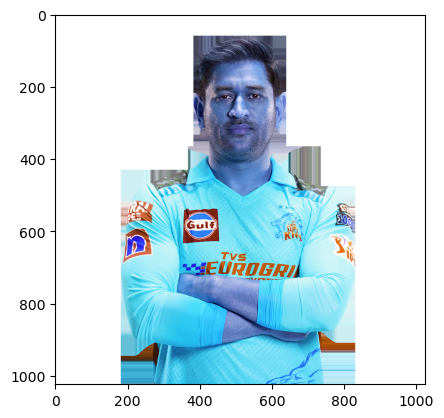

In [3]:
plt.imshow(img)

In [4]:
gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
gray.shape

(1024, 1024)

In [5]:
gray

array([[255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       ...,
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255],
       [255, 255, 255, ..., 255, 255, 255]], dtype=uint8)

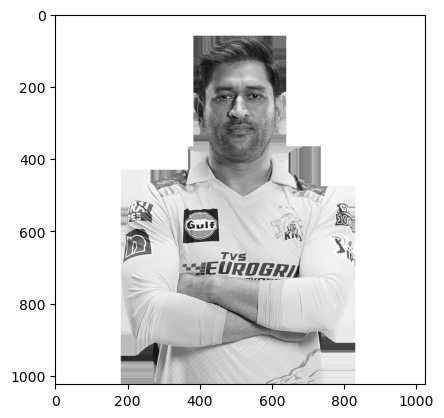

In [6]:
plt.imshow(gray,cmap='gray')

In [7]:



face_cascade = cv2.CascadeClassifier(r'./opencv\haar_cascade\haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier(r'./opencv\haar_cascade\haarcascade_eye.xml')

faces = face_cascade.detectMultiScale(gray,1.3,5)
faces


array([[387, 132, 252, 252]], dtype=int32)

In [8]:
(x,y,w,h)= faces[0]
x,y,w,h

(np.int32(387), np.int32(132), np.int32(252), np.int32(252))

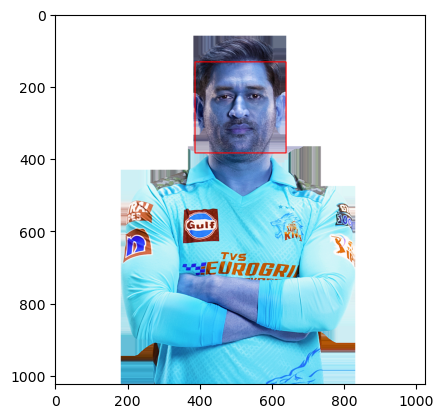

In [9]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

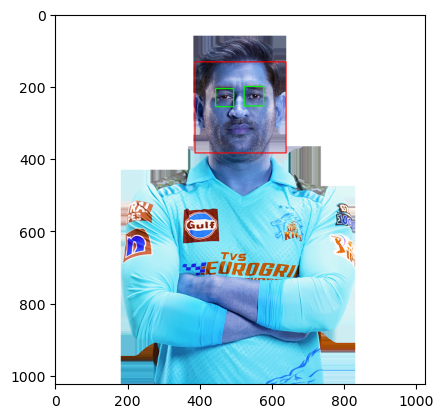

In [10]:
cv2.destroyAllWindows()
for (x,y,w,h) in faces :
    face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
    roi_gray = gray[y:y+h,x:x+w]
    roi_color = face_img[y:y+h,x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    
    for (ex,ey,ew,eh) in eyes:
        cv2.rectangle(roi_color,(ex,ey),(ex+ew,ey+eh),(0,255,0),2)
        
plt.figure()
plt.imshow(face_img, cmap = 'gray')
plt.show()
    

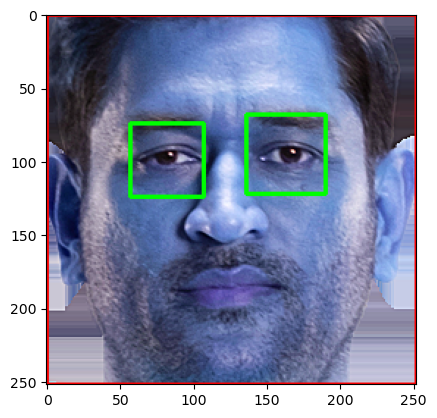

In [11]:
%matplotlib inline
plt.imshow(roi_color,cmap= 'gray')

In [12]:
def get_image_cropped_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray,1.3,5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h,x:x+w]
        roi_color = img[y:y+h,x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >=2:
            return roi_color
              

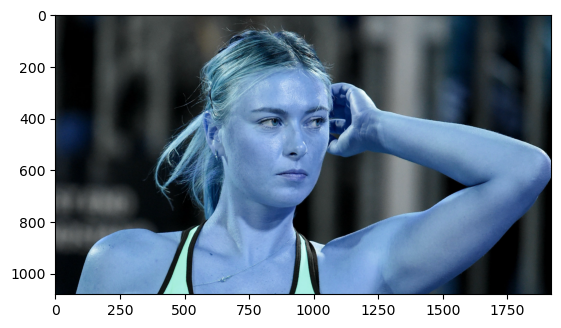

In [13]:
original_img = cv2.imread(r'./test_image\maria_s.jpg')
plt.imshow(original_img)

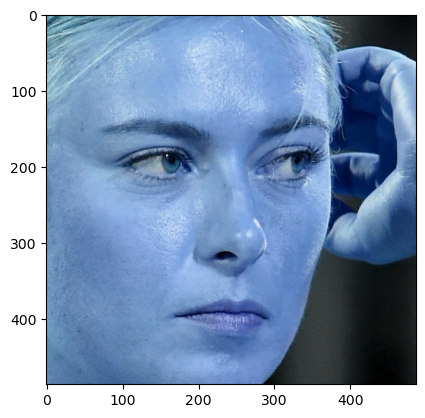

In [14]:
cropped_image = get_image_cropped_if_2_eyes(r'./test_image\maria_s.jpg')
plt.imshow(cropped_image)


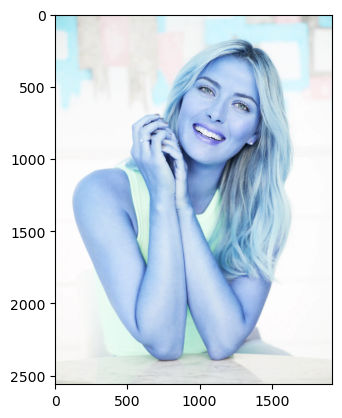

In [15]:
original_img_obstructed = cv2.imread(r'./test_image\maria-sharapova_r.jpg')
plt.imshow(original_img_obstructed)

In [16]:
cropped_image_obstructed = get_image_cropped_if_2_eyes(r'./test_image\maria-sharapova_r.jpg')
cropped_image_obstructed


In [17]:
path_to_data = "./dataset/"
path_to_cr_data = "./dataset\\cropped/"


In [18]:
import os 
img_dirs = []
for entry in os.scandir(path_to_data):
    if entry.is_dir():
        img_dirs.append(entry.path)


In [19]:
img_dirs

['./dataset/cropped',
 './dataset/maria_sharapoa',
 './dataset/ms_dhoni',
 './dataset/pv_sindhu',
 './dataset/rohit_sharma',
 './dataset/virat_kohli']

In [20]:
import shutil
if os.path.exists(path_to_cr_data):
    shutil.rmtree(path_to_cr_data)
os.mkdir(path_to_cr_data)

In [22]:
# ...existing code...
import os
import cv2

def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)      
    faces = face_cascade.detectMultiScale(gray,1.3,5)
    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h,x:x+w]
        roi_color = img[y:y+h,x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >=2:
            return roi_color
    #  implementation for cropping based on 2 eyes 
    

img_dirs = [r"./dataset/maria_sharapoa", r"./dataset/ms_dhoni", r"./dataset/pv_sindhu",r"./dataset/rohit_sharma",
            r"./dataset/virat_kohli"]
path_to_cr_data = r"./dataset/cropped"  

cropped_image_dirs = []
celebrity_file_names_dict = {}

for img_dir in img_dirs:
    count = 1
    celebrity_name = os.path.basename(img_dir)
    print(celebrity_name)
    
    celebrity_file_names_dict[celebrity_name] = []

    cropped_folder = os.path.join(path_to_cr_data, celebrity_name)
    if not os.path.exists(cropped_folder):
        os.makedirs(cropped_folder)
        cropped_image_dirs.append(cropped_folder)
        print("Generating cropped images in folder:", cropped_folder)
#new
    for count, entry in enumerate(os.scandir(img_dir), start=count):
        if entry.is_file() and entry.name.lower().endswith(('.jpg', '.jpeg', '.png')):
            # skip zero-byte files and log unreadable files
            try:
                if os.path.getsize(entry.path) == 0:
                    print("Skipping empty file:", entry.path)
                    continue
            except OSError:
                print("Can't stat file, skipping:", entry.path)
                continue

            # optional: try to read first to detect unreadable images early
            img_test = cv2.imread(entry.path)
            if img_test is None:
                print("cv2.imread failed, skipping:", entry.path)
                continue

            roi_color = get_cropped_image_if_2_eyes(entry.path)     
            if roi_color is not None:
                cropped_file_name = f"{celebrity_name}{count}.png"
                cropped_file_path = os.path.join(cropped_folder, cropped_file_name)
                cv2.imwrite(cropped_file_path, roi_color)
                celebrity_file_names_dict[celebrity_name].append(cropped_file_path)
# ...existing code...
print("Cropped image directories:", cropped_image_dirs)
print("Celebrity file names dictionary:", celebrity_file_names_dict)


maria_sharapoa
Can't stat file, skipping: ./dataset/maria_sharapoa\maria-sharapova-from-russia-in-action-against-amy-frazier-from-the-usa-at-the-lawn-tennis-championships-in-wimbledon-london-editorial-use-only-no-mobile-phone-use-2D33KKD.jpg
ms_dhoni
Generating cropped images in folder: ./dataset/cropped\ms_dhoni
Can't stat file, skipping: ./dataset/ms_dhoni\leeds-uk-6th-july-2019-indias-ms-dhoni-during-the-icc-cricket-world-cup-2019-match-between-india-and-sri-lanka-at-emerald-headingley-leeds-on-saturday-6th-july-2019-credit-mark-fletcher-mi-new.jpg
pv_sindhu
Generating cropped images in folder: ./dataset/cropped\pv_sindhu
rohit_sharma
Generating cropped images in folder: ./dataset/cropped\rohit_sharma
virat_kohli
Generating cropped images in folder: ./dataset/cropped\virat_kohli
Cropped image directories: ['./dataset/cropped\\ms_dhoni', './dataset/cropped\\pv_sindhu', './dataset/cropped\\rohit_sharma', './dataset/cropped\\virat_kohli']
Celebrity file names dictionary: {'maria_sharap

In [23]:
def get_cropped_image_if_2_eyes(image_path):
    img = cv2.imread(image_path)

    if img is None:
        print("ERROR: Unable to read image:", image_path)
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)      
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)

    for (x,y,w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)

        if len(eyes) >= 2:
            return roi_color

    return None

In [24]:
if not os.path.exists(img_dir):
    print("Directory does not exist:", img_dir)

**Feature Engineering**

In [25]:
import numpy as np
import pywt
import cv2    

def w2d(img, mode='haar', level=1):
    imArray = img
    imArray = cv2.cvtColor( imArray,cv2.COLOR_RGB2GRAY )
    imArray =  np.float32(imArray)   
    imArray /= 255; 
    coeffs=pywt.wavedec2(imArray, mode, level=level)

    coeffs_H=list(coeffs)  
    coeffs_H[0] *= 0;  

    imArray_H=pywt.waverec2(coeffs_H, mode);
    imArray_H *= 255;
    imArray_H =  np.uint8(imArray_H)

    return imArray_H

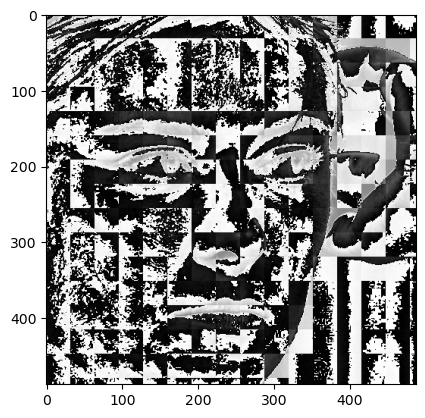

In [26]:
im_har = w2d(cropped_image,'db1',5)
plt.imshow(im_har, cmap='gray')

In [27]:
celebrity_file_names_dict

{'maria_sharapoa': ['./dataset/cropped\\maria_sharapoa\\maria_sharapoa4.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa5.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa6.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa7.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa9.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa10.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa11.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa13.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa26.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa27.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa30.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa31.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa32.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa33.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa34.png',
  './dataset/cropped\\maria_sharapoa\\maria_sharapoa35.png',
  './datase

In [29]:
class_dict = {
    "maria_sharapoa": 0,
    "ms_dhoni": 1,
    "pv_sindhu": 2,
    "rohit_sharma": 3,
    "virat_kohli": 4
}



In [30]:
import os
import cv2
import numpy as np

class_dict = {"maria_sharapoa": 0, "ms_dhoni": 1, "pv_sindhu": 2, "rohit_sharma": 3, "virat_kohli": 4}


X, y = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (224, 224))
        img_har = w2d(img, 'db1', 5)
        scalled_img_har = cv2.resize(img_har, (224, 224))
        combined_img = np.vstack((scalled_raw_img.reshape(224 * 224 * 3, 1), scalled_img_har.reshape(224 * 224, 1)))
        X.append(combined_img)
        y.append(class_dict[celebrity_name])


In [31]:
len(X[0])

200704

In [32]:
224*224*3 + 224*224

200704

In [33]:
X[0]

array([[224],
       [232],
       [239],
       ...,
       [ 29],
       [162],
       [255]], dtype=uint8)

In [34]:
X = np.array(X).reshape(len(X),200704).astype(float)
X.shape

(384, 200704)

In [ ]:
X[0]

array([224., 232., 239., ...,  29., 162., 255.])

In [ ]:
hh

# Model Training

In [ ]:
# for 32*32*3 + 32*32 image size

import os
import cv2
import numpy as np

class_dict = {"maria_sharapoa": 0, "ms_dhoni": 1, "pv_sindhu": 2, "rohit_sharma": 3, "virat_kohli": 4}


X_1, y_1 = [], []
for celebrity_name, training_files in celebrity_file_names_dict.items():
    for training_image in training_files:
        img = cv2.imread(training_image)
        if img is None:
            continue
        scalled_raw_img = cv2.resize(img, (32, 32))
        img_har = w2d(img, 'db1', 5)
        scalled_img_har = cv2.resize(img_har, (32, 32))
        combined_img = np.vstack((scalled_raw_img.reshape(32 * 32 * 3, 1), scalled_img_har.reshape(32 * 32, 1)))
        X_1.append(combined_img)
        y_1.append(class_dict[celebrity_name])


In [ ]:
X_1 = np.array(X_1).reshape(len(X_1),4096).astype(float)
X_1.shape

(362, 4096)

In [ ]:
import os
import cv2
import numpy as np
from tensorflow import keras
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

X_32 = np.array(X_1)
y_32 = np.array(y_1)

X_train, X_test, y_train, y_test = train_test_split(X_32, y_32, test_size=0.2, random_state=42)

X_train = X_train / 255.0
X_test = X_test / 255.0

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Resize to 32x32 (original CNN)
common_size = (32, 32)
X_train_resized = np.array([cv2.resize(img, common_size) for img in X_train])
X_test_resized = np.array([cv2.resize(img, common_size) for img in X_test])

X_train_resized = X_train_resized.reshape(-1, common_size[0], common_size[1], 1)
X_test_resized = X_test_resized.reshape(-1, common_size[0], common_size[1], 1)

# Original 32x32 CNN Model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)))
model.add(MaxPooling2D((2, 2)))
model.add(Conv2D(64, (3, 3), activation='relu'))
model.add(MaxPooling2D((2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(5, activation='softmax'))

print("32x32 CNN model created")

32x32 CNN model created


c:\Users\HP\anaconda3\envs\old_project2\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,501 (1.20 MB)

 Trainable params: 314,501 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', min_delta=0.001,
    patience=30,
    verbose=1,
    mode='auto',
    baseline=None,
    restore_best_weights=True,
    start_from_epoch=0)

print("Training 32x32 CNN...")
model.fit(X_train_resized, y_train, epochs=100, batch_size=64, 
          validation_data=(X_test_resized, y_test), callbacks=early_stopping)

Training 32x32 CNN...
Epoch 1/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 95ms/step - accuracy: 0.2734 - loss: 1.5605 - val_accuracy: 0.5342 - val_loss: 1.4581
Epoch 2/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4083 - loss: 1.4933 - val_accuracy: 0.3973 - val_loss: 1.4132
Epoch 3/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3010 - loss: 1.4743 - val_accuracy: 0.4932 - val_loss: 1.3901
Epoch 4/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.4671 - loss: 1.4232 - val_accuracy: 0.5205 - val_loss: 1.3215
Epoch 5/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - accuracy: 0.4533 - loss: 1.3571 - val_accuracy: 0.5753 - val_loss: 1.2421
Epoch 6/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - accuracy: 0.4775 - loss: 1.2608 - val_accuracy: 0.5753 - val_loss: 1.1609
Epoch 7/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.5329 - loss: 1.1645 - val_accuracy: 0.6849 - val_loss: 1.0692
Epoch 8/100
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5398 - loss: 1.1068 - val_accura

In [ ]:
# Evaluate on training and test sets
train_loss, train_accuracy = model.evaluate(X_train_resized, y_train)
test_loss, test_accuracy = model.evaluate(X_test_resized, y_test)

print(f'\n=== Accuracy Metrics ===')
print(f'Train Accuracy: {train_accuracy:.4f}')
print(f'Validation/Test Accuracy: {test_accuracy:.4f}')

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7682 - loss: 0.6360
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6164 - loss: 0.8198

=== Accuracy Metrics ===
Train Accuracy: 0.7682
Validation/Test Accuracy: 0.6164


In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Predict on the preprocessed/resized test set
y_pred_prob = model.predict(X_test_resized)
y_pred = np.argmax(y_pred_prob, axis=1)

# Convert one-hot encoded y_test to class labels
if hasattr(y_test, 'ndim') and y_test.ndim > 1 and y_test.shape[1] > 1:
    y_true = np.argmax(y_test, axis=1)
else:
    y_true = y_test.astype(int)

# Build readable target names from `class_dict`
try:
    inv_class_dict = {v: k for k, v in class_dict.items()}
    target_names = [inv_class_dict[i] for i in range(len(inv_class_dict))]
except Exception:
    target_names = None

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=target_names))

print('\n=== Confusion Matrix ===')
cm = confusion_matrix(y_true, y_pred)
print(cm)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step

=== Classification Report ===
                precision    recall  f1-score   support

maria_sharapoa       0.83      0.86      0.85        29
      ms_dhoni       0.00      0.00      0.00         4
     pv_sindhu       0.54      0.70      0.61        10
  rohit_sharma       0.42      0.38      0.40        13
   virat_kohli       0.44      0.47      0.46        17

      accuracy                           0.62        73
     macro avg       0.45      0.48      0.46        73
  weighted avg       0.58      0.62      0.60        73


=== Confusion Matrix ===
[[25  0  3  0  1]
 [ 1  0  2  1  0]
 [ 2  0  7  0  1]
 [ 0  0  0  5  8]
 [ 2  0  1  6  8]]


c:\Users\HP\anaconda3\envs\old_project2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\anaconda3\envs\old_project2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\HP\anaconda3\envs\old_project2\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", 

In [ ]:
# autogluon
import pandas as pd
print(X_1.shape)
df = pd.DataFrame(X_1)
df["label"] = y_1

(362, 4096)


In [ ]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(label="label").fit(
    train_df,
    time_limit=600
)

c:\Users\HP\anaconda3\envs\old_project2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
No path specified. Models will be saved in: "AutogluonModels\ag-20260307_174555"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       0.85 GB / 7.35 GB (11.5%)
Disk Space Avail:   116.52 GB / 195.31 GB (59.7%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular

In [ ]:
predictor.leaderboard(test_df)

,model,score_test,score_val,eval_metric,pred_time_test,pred_time_val,fit_time,pred_time_test_marginal,pred_time_val_marginal,fit_time_marginal,stack_level,can_infer,fit_order
0,RandomForestEntr,0.835616,0.810345,accuracy,0.205190,0.074206,2.280496,0.205190,0.074206,2.280496,1,True,2
1,ExtraTreesEntr,0.821918,0.775862,accuracy,0.235173,0.057094,2.112232,0.235173,0.057094,2.112232,1,True,4
2,WeightedEnsemble_L2,0.821918,0.844828,accuracy,0.995702,0.375475,8.776761,0.054061,0.002377,0.040285,2,True,6
3,RandomForestGini,0.794521,0.793103,accuracy,0.220485,0.053296,2.263496,0.220485,0.053296,2.263496,1,True,1
4,ExtraTreesGini,0.794521,0.793103,accuracy,0.228513,0.053586,2.070751,0.228513,0.053586,2.070751,1,True,3
5,NeuralNetTorch,0.794521,0.827586,accuracy,0.736451,0.298892,6.455980,0.736451,0.298892,6.455980,1,True,5


In [ ]:
predictor.evaluate(test_df)


{'accuracy': 0.821917808219178,
 'balanced_accuracy': np.float64(0.7017350600717741),
 'mcc': 0.760592535227776}

In [ ]:
X_test = test_df.drop(columns=["label"])

preds = predictor.predict(X_test)
print(preds)

163    0
33     0
15     2
322    4
57     0
      ..
297    0
82     0
94     0
341    4
303    4
Name: label, Length: 73, dtype: int64


In [ ]:
from autogluon.tabular.configs.hyperparameter_configs import get_hyperparameter_config
hyperparameters = get_hyperparameter_config('default')[0]

hyperparameters

In [ ]:
from autogluon.tabular.configs.hyperparameter_configs import get_hyperparameter_config

# get default hyperparameter config
hyperparameters = get_hyperparameter_config('default')

# see keys (models AutoGluon will train)
print(hyperparameters.keys())
first_model_name = list(hyperparameters.keys())[5]  # e.g., 'GBM'
first_model_hyperparams = hyperparameters[first_model_name]

print(f"First model: {first_model_name}")
print(first_model_hyperparams)


dict_keys(['NN_TORCH', 'GBM', 'CAT', 'XGB', 'FASTAI', 'RF', 'XT'])
First model: RF
[{'criterion': 'gini', 'ag_args': {'name_suffix': 'Gini', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'entropy', 'ag_args': {'name_suffix': 'Entr', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'squared_error', 'ag_args': {'name_suffix': 'MSE', 'problem_types': ['regression', 'quantile']}}]


In [ ]:
from autogluon.tabular.configs.hyperparameter_configs import get_hyperparameter_config

# get default hyperparameters
hyperparameters = get_hyperparameter_config('default')

# select first model (RF)
first_model_name = list(hyperparameters.keys())[5]
first_model_hyperparams = hyperparameters[first_model_name]

# filter only classification
classification_hyperparams = [
    hp for hp in first_model_hyperparams 
    if 'binary' in hp['ag_args']['problem_types'] or 'multiclass' in hp['ag_args']['problem_types']
]

print(f"First model for classification: {first_model_name}")
print(classification_hyperparams)

First model for classification: RF
[{'criterion': 'gini', 'ag_args': {'name_suffix': 'Gini', 'problem_types': ['binary', 'multiclass']}}, {'criterion': 'entropy', 'ag_args': {'name_suffix': 'Entr', 'problem_types': ['binary', 'multiclass']}}]


In [ ]:
from autogluon.tabular import TabularPredictor

predictor = TabularPredictor(label="label").fit(
    train_data=train_df,
    hyperparameters={'RF': classification_hyperparams}
)

No path specified. Models will be saved in: "AutogluonModels\ag-20260307_184830"
Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.12.0
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          12
Pytorch Version:    2.10.0+cpu
CUDA Version:       CUDA is not available
Memory Avail:       1.00 GB / 7.35 GB (13.7%)
Disk Space Avail:   116.50 GB / 195.31 GB (59.6%)
No presets specified! To achieve strong results with AutoGluon, it is recommended to use the available presets. Defaulting to `'medium'`...
	Recommended Presets (For more details refer to https://auto.gluon.ai/stable/tutorials/tabular/tabular-essentials.html#presets):
	presets='extreme'  : New in v1.5: The state-of-the-art for tabular data. Massively better than 'best' on datasets <100000 samples by using new Tabular Foundation Models (TFMs) meta-learned on https://tabarena.ai: TabPFNv2, TabICL, Mitr

In [ ]:
results = predictor.evaluate(test_df)
print(results)


{'accuracy': 0.8356164383561644, 'balanced_accuracy': np.float64(0.7088843813387424), 'mcc': 0.7774655084312724}
